In [68]:
# Cell 0 — Imports
import numpy as np
import matplotlib.pyplot as plt
from utils.data_utils import ImageNetSubset, WeatherImageNetSubset

In [69]:
# Cell 1 — Load embeddings and class names
orig_emb      = np.load("weather_augmentations/embeddings_original.npy")   # (N, D)
aug_emb       = np.load("weather_augmentations/embeddings_augmented.npy")  # (N, D)
label_emb     = np.load("weather_augmentations/embeddings_labels.npy")     # (C, D)
class_ids     = np.load("weather_augmentations/class_ids.npy")             # (N,)
weather_labels = np.load("weather_augmentations/weather_labels.npy", allow_pickle=True)


orig_dataset = ImageNetSubset(root="data/imnet_subset", split="train", transform=None)
class_names  = orig_dataset.classes  # dict {0: 'name', ...}

In [70]:
# Cell 3 — Per-sample cosine sim: image → its GT label text embedding
# dot product == cosine sim since both are L2-normalised
gt_label_emb = label_emb[class_ids]                        # (N, D)
orig_sim     = (orig_emb * gt_label_emb).sum(axis=1)       # (N,)
aug_sim      = (aug_emb  * gt_label_emb).sum(axis=1)       # (N,)

print("Image to GT label cosine similarity:")
print(f"{'':30s} {'mean':>8} {'std':>8} {'min':>8} {'max':>8}")
print(f"{'Original':30s} {orig_sim.mean():>8.4f} {orig_sim.std():>8.4f} {orig_sim.min():>8.4f} {orig_sim.max():>8.4f}")
print(f"{'Augmented':30s} {aug_sim.mean():>8.4f} {aug_sim.std():>8.4f} {aug_sim.min():>8.4f} {aug_sim.max():>8.4f}")

Image to GT label cosine similarity:
                                   mean      std      min      max
Original                         0.2606   0.0319   0.0797   0.3648
Augmented                        0.2566   0.0312   0.0676   0.3718


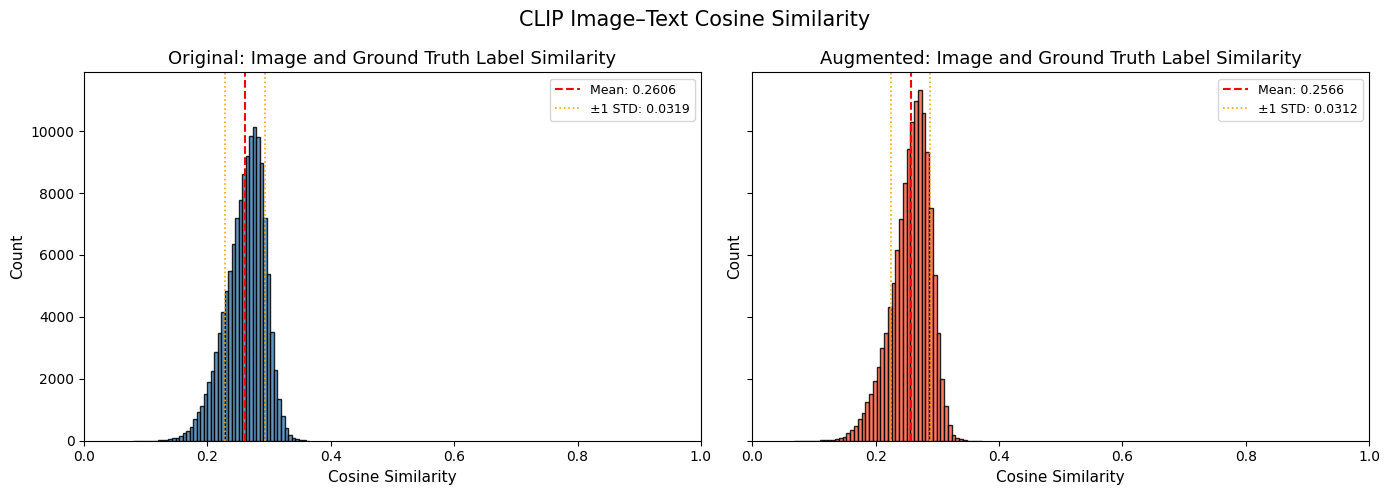

In [71]:
# Cell 4 — Overall distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, sims, label, color in zip(
    axes,
    [orig_sim, aug_sim],
    ["Original", "Augmented"],
    ["steelblue", "tomato"]
):
    ax.hist(sims, bins=50, color=color, edgecolor='black', alpha=0.85)
    ax.axvline(sims.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {sims.mean():.4f}')
    ax.axvline(sims.mean() - sims.std(), color='orange', linestyle=':', linewidth=1.2, label=f'±1 STD: {sims.std():.4f}')
    ax.axvline(sims.mean() + sims.std(), color='orange', linestyle=':', linewidth=1.2)
    ax.set_title(f'{label}: Image and Ground Truth Label Similarity', fontsize=13)
    ax.set_xlabel('Cosine Similarity', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=9)

plt.suptitle('CLIP Image–Text Cosine Similarity', fontsize=15)
plt.tight_layout()
plt.savefig('cosine_sim_image_text.png', dpi=800)
plt.show()

In [72]:

# Cell 5 — Per-weather breakdown
print("\nPer-weather image-text cosine similarity:")
print(f"{'':10} {'':>6}  {'':>34} {'':>34}")
print(f"{'Weather':<10} {'N':>6}  {'Orig mean':>8} {'Orig std':>8} {'Orig min':>8} {'Orig max':>8}  {'Aug mean':>8} {'Aug std':>8} {'Aug min':>8} {'Aug max':>8}")
print("-" * 100)
for weather in ["sunny", "fog", "rain", "snow"]:
    mask = weather_labels == weather
    print(f"{weather:<10} {mask.sum():>6}  "
          f"{orig_sim[mask].mean():>8.4f} "
          f"{orig_sim[mask].std():>8.4f} "
          f"{orig_sim[mask].min():>8.4f} "
          f"{orig_sim[mask].max():>8.4f}  "
          f"{aug_sim[mask].mean():>8.4f} "
          f"{aug_sim[mask].std():>8.4f} "
          f"{aug_sim[mask].min():>8.4f} "
          f"{aug_sim[mask].max():>8.4f}")
# print("\nPer-weather image→text cosine similarity:")
# print(f"{'Weather':<10} {'N':>6}  {'Orig mean':>10} {'Aug mean':>10} {'Drop':>8}")
# print("-" * 52)
# for weather in ["sunny", "fog", "rain", "snow"]:
#     mask = weather_labels == weather
#     print(f"{weather:<10} {mask.sum():>6}  "
#           f"{orig_sim[mask].mean():>10.4f} "
#           f"{aug_sim[mask].mean():>10.4f} "
#           f"{sim_drop[mask].mean():>8.4f}")


Per-weather image-text cosine similarity:
                                                                                        
Weather         N  Orig mean Orig std Orig min Orig max  Aug mean  Aug std  Aug min  Aug max
----------------------------------------------------------------------------------------------------
sunny       32463    0.2608   0.0319   0.0993   0.3612    0.2579   0.0301   0.0955   0.3615
fog         32464    0.2606   0.0318   0.0801   0.3643    0.2596   0.0309   0.1132   0.3495
rain        32464    0.2606   0.0319   0.0848   0.3648    0.2559   0.0315   0.0676   0.3718
snow        32464    0.2606   0.0319   0.0797   0.3589    0.2529   0.0320   0.0917   0.3457


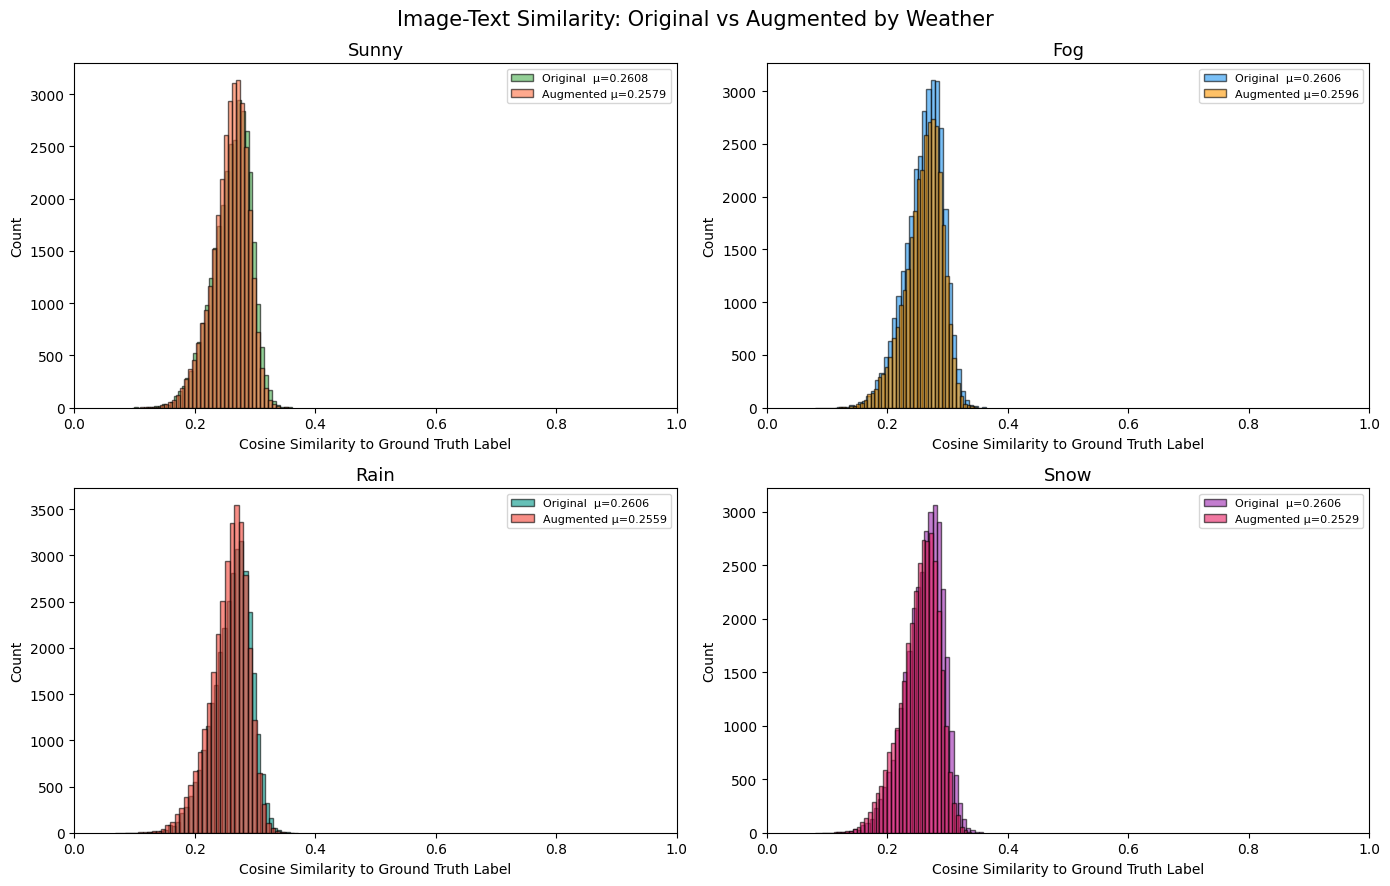

In [73]:
# Cell 6 — Per-weather plot: orig vs aug side by side
weather_types = ["sunny", "fog", "rain", "snow"]
colors_orig   = ["#4CAF50", "#2196F3", "#009688", "#9C27B0"]
colors_aug    = ["#FF7043", "#FF9800", "#F44336", "#E91E63"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, weather, co, ca in zip(axes, weather_types, colors_orig, colors_aug):
    mask = weather_labels == weather
    ax.hist(orig_sim[mask], bins=40, color=co, edgecolor='black', alpha=0.6, label=f'Original  μ={orig_sim[mask].mean():.4f}')
    ax.hist(aug_sim[mask],  bins=40, color=ca, edgecolor='black', alpha=0.6, label=f'Augmented μ={aug_sim[mask].mean():.4f}')
    ax.set_title(f'{weather.capitalize()}', fontsize=13)
    ax.set_xlabel('Cosine Similarity to Ground Truth Label', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)

fig.suptitle('Image-Text Similarity: Original vs Augmented by Weather', fontsize=15)
plt.tight_layout()
plt.savefig('cosine_sim_per_weather_text.png', dpi=800)
plt.show()

In [74]:
# Cell 7 — Per-class breakdown
print("\nPer-class image→text similarity (sorted by aug mean):")
max_len = max(len(v) for v in class_names.values())
print(f"  {'Class':<{max_len}}  {'N':>5}  {'Orig':>8}  {'Aug':>8}  {'Drop':>8}")
print("  " + "-" * (max_len + 38))

class_stats = []
for class_id in np.unique(class_ids):
    mask = class_ids == class_id
    class_stats.append((class_id, mask.sum(), orig_sim[mask].mean(), aug_sim[mask].mean()))

for class_id, n, o_mean, a_mean in sorted(class_stats, key=lambda x: x[3]):
    print(f"  {class_names[class_id]:<{max_len}}  {n:>5}  {o_mean:>8.4f}  {a_mean:>8.4f}")


Per-class image→text similarity (sorted by aug mean):
  Class                      N      Orig       Aug      Drop
  -----------------------------------------------------------
  jeep                    1300    0.1963    0.1947
  alp                     1300    0.2182    0.2027
  promontory              1300    0.2213    0.2106
  cliff                   1300    0.2173    0.2116
  pier                    1300    0.2056    0.2170
  beach wagon             1300    0.2233    0.2175
  lakeside                1300    0.2193    0.2184
  sandbar                 1300    0.2280    0.2218
  valley                  1300    0.2180    0.2224
  seashore                1300    0.2229    0.2242
  solar dish              1300    0.2398    0.2250
  beacon                  1300    0.2344    0.2319
  dragonfly               1300    0.2723    0.2358
  castle                  1300    0.2270    0.2387
  mountain bike           1300    0.2449    0.2395
  acorn                   1300    0.2582    0.2403
  fire

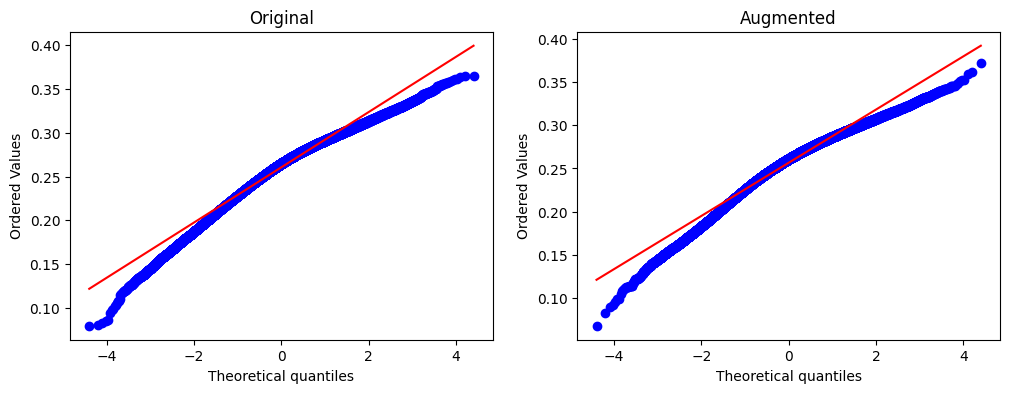

Original:
  Skewness: -0.6124
  Kurtosis: 0.3791
Augmented:
  Skewness: -0.6748
  Kurtosis: 0.4878
Original: stat=7489.3141, p=0.0000e+00
Augmented: stat=9029.8248, p=0.0000e+00


In [75]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sims, label in zip(axes, [orig_sim, aug_sim], ["Original", "Augmented"]):
    stats.probplot(sims, dist="norm", plot=ax)
    ax.set_title(label)
plt.show()

for sims, label in [(orig_sim, "Original"), (aug_sim, "Augmented")]:
    print(f"{label}:")
    print(f"  Skewness: {stats.skew(sims):.4f}")
    print(f"  Kurtosis: {stats.kurtosis(sims):.4f}")
    
for sims, label in [(orig_sim, "Original"), (aug_sim, "Augmented")]:
    stat, p = stats.normaltest(sims)
    print(f"{label}: stat={stat:.4f}, p={p:.4e}")

In [76]:
# IQR-based outlier detection
Q1 = np.percentile(aug_sim, 25)
Q3 = np.percentile(aug_sim, 75)
IQR = Q3 - Q1
threshold = Q1 - 1.5 * IQR

bad_idx = np.where(aug_sim < threshold)[0]

print(f"Q1:        {Q1:.4f}")
print(f"Q3:        {Q3:.4f}")
print(f"IQR:       {IQR:.4f}")
print(f"Threshold: {threshold:.4f}")
print(f"Outliers:  {len(bad_idx)} ({len(bad_idx)/len(aug_sim)*100:.2f}%)")

print("\nWeather distribution:")
for weather in ["sunny", "fog", "rain", "snow"]:
    n = (weather_labels[bad_idx] == weather).sum()
    pct = n / len(bad_idx) * 100
    print(f"  {weather:<8}: {n} ({pct:.1f}%)")

Q1:        0.2383
Q3:        0.2789
IQR:       0.0406
Threshold: 0.1774
Outliers:  2156 (1.66%)

Weather distribution:
  sunny   : 401 (18.6%)
  fog     : 457 (21.2%)
  rain    : 589 (27.3%)
  snow    : 709 (32.9%)


In [77]:
# Cell 8 — Outlier flagging (based on augmented similarity)
threshold = aug_sim.mean() - 2 * aug_sim.std()
bad_idx   = np.where(aug_sim < threshold)[0]

print(f"\nOutliers (aug similarity < {threshold:.4f}): {len(bad_idx)} images")
print("  Weather distribution:")
for weather in ["sunny", "fog", "rain", "snow"]:
    n = (weather_labels[bad_idx] == weather).sum()
    print(f"    {weather:<8}: {n}")

print("  Class distribution (top 10):")
unique, counts = np.unique(class_ids[bad_idx], return_counts=True)
for class_id, count in sorted(zip(unique, counts), key=lambda x: -x[1])[:10]:
    print(f"    {class_names[class_id]}: {count}")


Outliers (aug similarity < 0.1941): 5430 images
  Weather distribution:
    sunny   : 1110
    fog     : 1134
    rain    : 1451
    snow    : 1735
  Class distribution (top 10):
    jeep: 682
    alp: 446
    cliff: 329
    solar dish: 326
    pier: 283
    promontory: 245
    dragonfly: 237
    sandbar: 218
    beach wagon: 207
    lakeside: 200


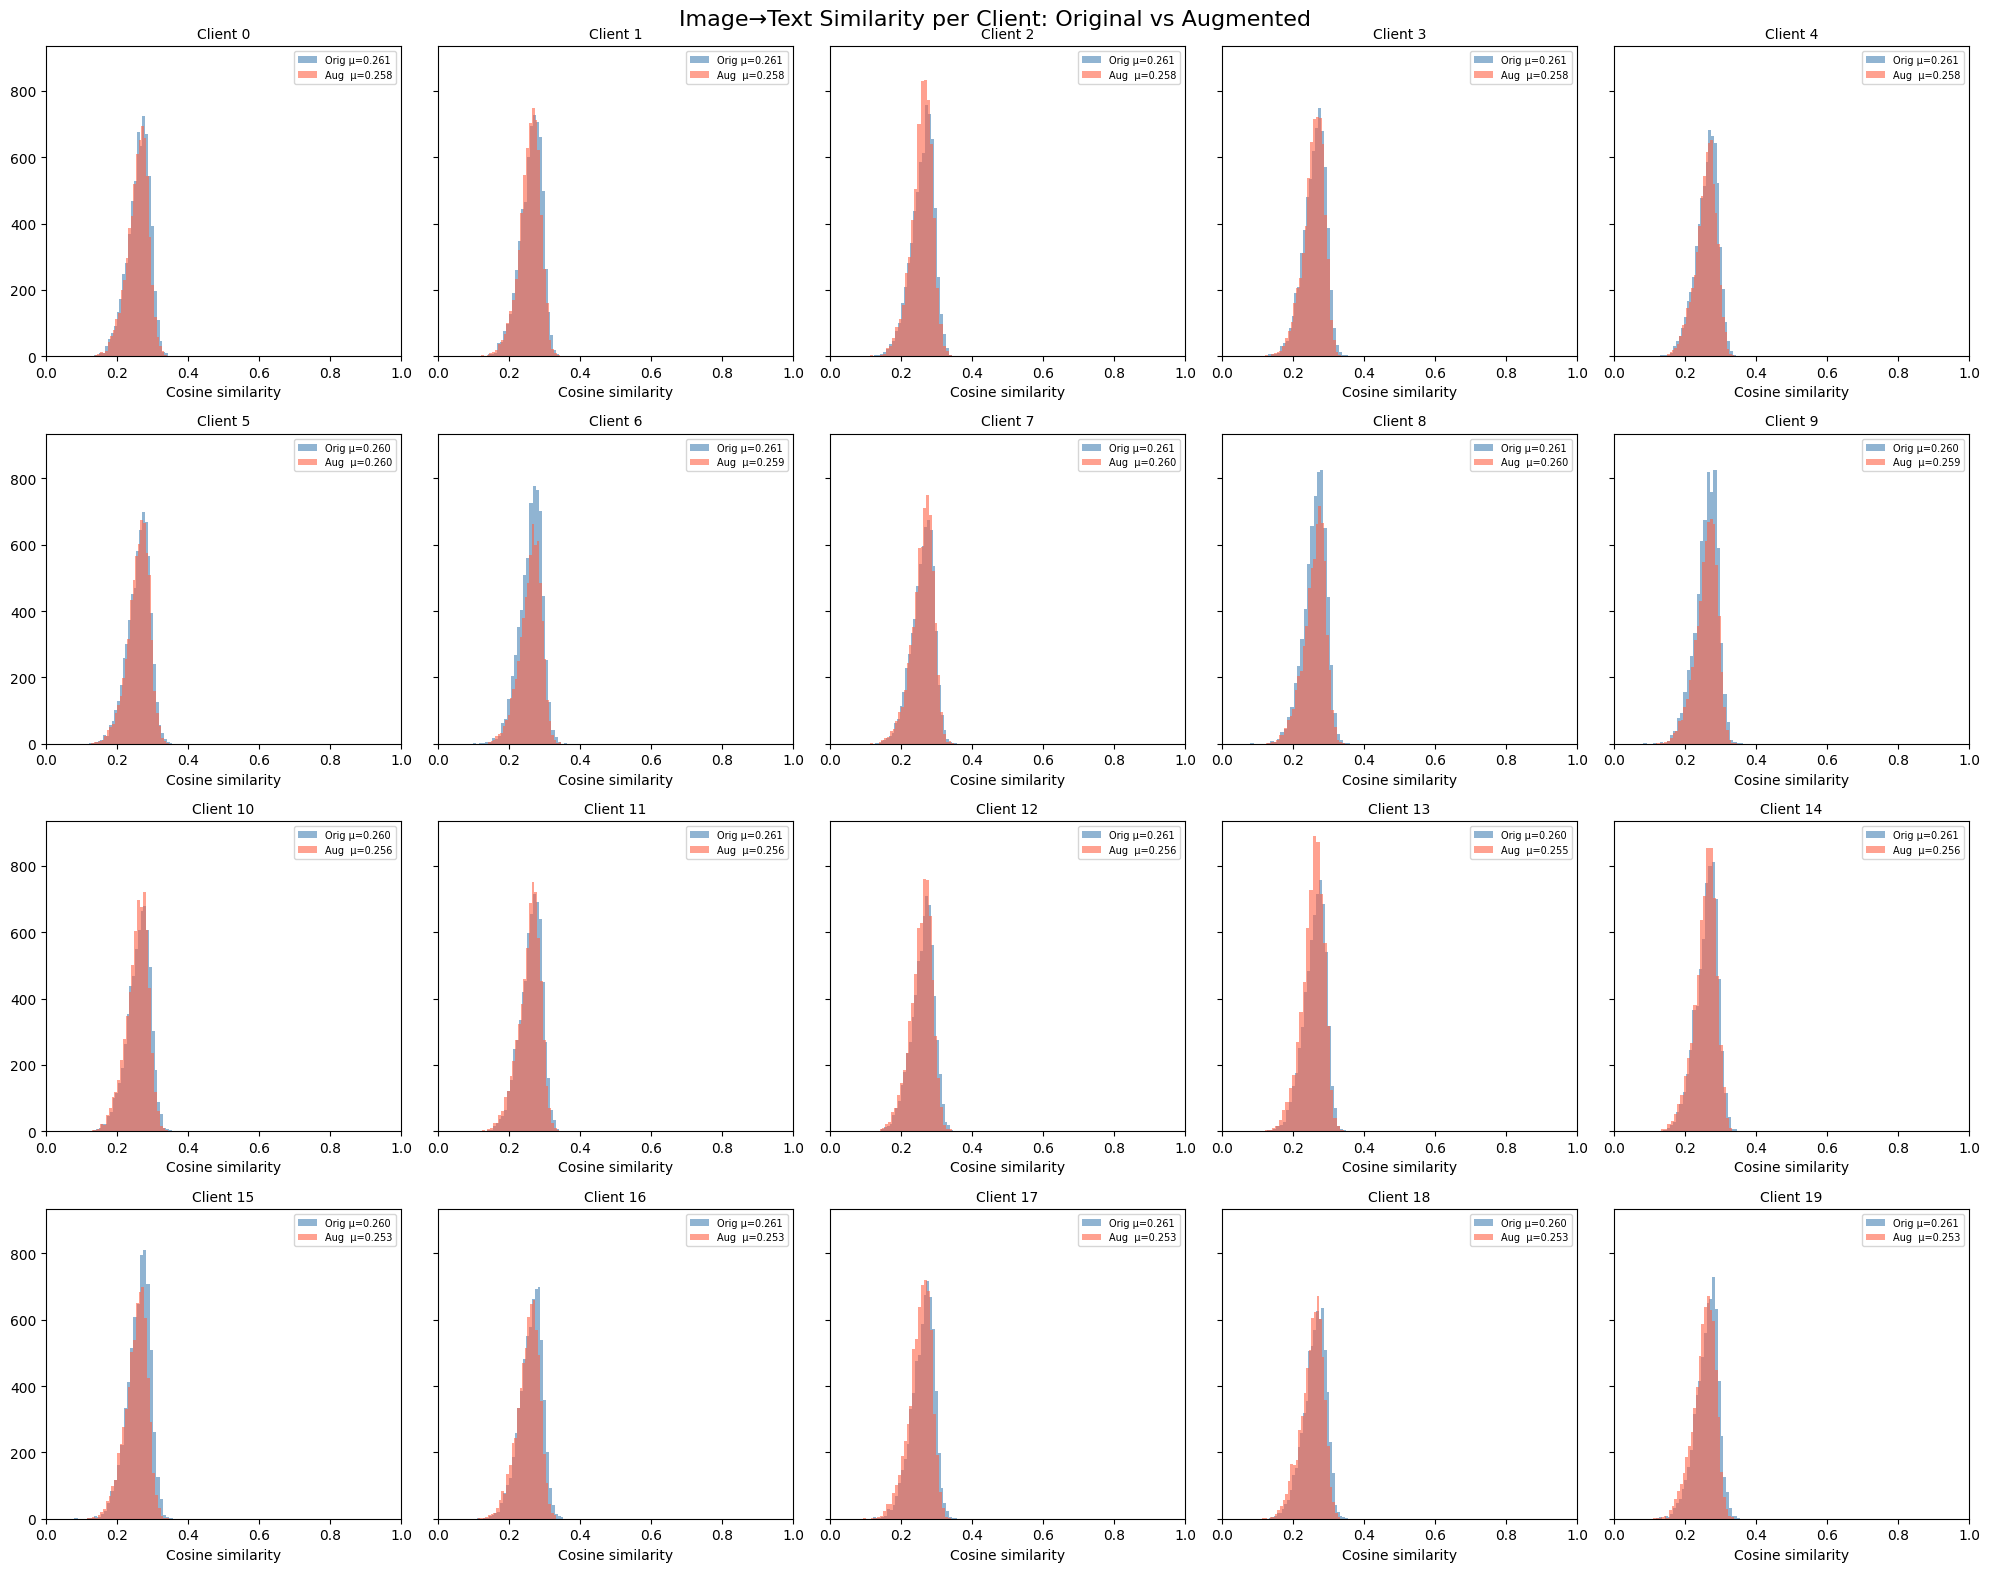

In [78]:
# Cell 9 — Per-client breakdown (if using FL clients)
from utils.data_utils import WeatherImageNetSubset
from utils.fl_utils import init_clients

weather_dataset = WeatherImageNetSubset(root="data/imnet_subset_weather_aug", split="train", transform=None)
clients = init_clients(weather_dataset, 20, batch_size=64, dl_kwargs=None, transform=None)
client_idx_list = [client.subset for client in clients]

fig, axes = plt.subplots(4, 5, figsize=(20, 16), sharey=True)
axes = axes.flatten()

for i, idxs in enumerate(client_idx_list):
    o_sims = orig_sim[idxs]
    a_sims = aug_sim[idxs]
    axes[i].hist(o_sims, bins=30, color='steelblue', alpha=0.6, label=f'Orig μ={o_sims.mean():.3f}')
    axes[i].hist(a_sims, bins=30, color='tomato',    alpha=0.6, label=f'Aug  μ={a_sims.mean():.3f}')
    axes[i].set_title(f"Client {i}", fontsize=10)
    axes[i].set_xlabel("Cosine similarity")
    axes[i].set_xlim(0, 1)
    axes[i].legend(fontsize=7)

plt.suptitle("Image→Text Similarity per Client: Original vs Augmented", fontsize=16)
plt.tight_layout()
plt.show()

In [79]:
# Re-load datasets just for index verification (no transform needed)
orig_dataset    = ImageNetSubset(root="data/imnet_subset", split="train", transform=None)
weather_dataset = WeatherImageNetSubset(root="data/imnet_subset_weather_aug", split="train", transform=None)

# Check class_ids match dataset targets
assert np.array_equal(class_ids, np.array(orig_dataset.targets)), \
    "class_ids.npy does not match orig_dataset.targets"

# Check weather_labels match dataset weather list
assert np.array_equal(weather_labels, np.array(weather_dataset.weathers)), \
    "weather_labels.npy does not match weather_dataset.weathers"

# Check label_emb rows correspond to the right class names
# label_emb[i] should be the embedding for class i
for i, name in class_names.items():
    assert i < label_emb.shape[0], f"class_id {i} ({name}) has no label embedding"

print("Index alignment verified:")
print(f"  class_ids     matches orig_dataset.targets")
print(f"  weather_labels matches weather_dataset.weathers")
print(f"  label_emb     has an entry for all {len(class_names)} classes")

Index alignment verified:
  class_ids     matches orig_dataset.targets
  weather_labels matches weather_dataset.weathers
  label_emb     has an entry for all 100 classes


In [80]:
# Print first few to inspect
for i in range(5):
    print(f"class_id {i} → '{class_names[i]}' → prompt: 'a photo of a {class_names[i]}'")
    print(f"  label_emb[{i}] norm: {np.linalg.norm(label_emb[i]):.4f}")  # should be ~1.0
    
    
print(f"orig_emb   norms: min={np.linalg.norm(orig_emb, axis=1).min():.4f}  max={np.linalg.norm(orig_emb, axis=1).max():.4f}")
print(f"label_emb  norms: min={np.linalg.norm(label_emb, axis=1).min():.4f}  max={np.linalg.norm(label_emb, axis=1).max():.4f}")

class_id 0 → 'ostrich' → prompt: 'a photo of a ostrich'
  label_emb[0] norm: 0.9995
class_id 1 → 'bald eagle' → prompt: 'a photo of a bald eagle'
  label_emb[1] norm: 1.0000
class_id 2 → 'vulture' → prompt: 'a photo of a vulture'
  label_emb[2] norm: 1.0000
class_id 3 → 'great grey owl' → prompt: 'a photo of a great grey owl'
  label_emb[3] norm: 1.0000
class_id 4 → 'Komodo dragon' → prompt: 'a photo of a Komodo dragon'
  label_emb[4] norm: 1.0000
orig_emb   norms: min=1.0000  max=1.0000
label_emb  norms: min=0.9995  max=1.0000


In [81]:
scores    = orig_emb[:10] @ label_emb.T   # (10, 100)
predicted = scores.argmax(axis=1)
for i in range(10):
    true_name = class_names[class_ids[i]]
    pred_name = class_names[predicted[i]]
    print(f"GT: {true_name:<30}  Pred: {pred_name:<30}  Score: {scores[i, class_ids[i]]:.4f}")

GT: ostrich                         Pred: ostrich                         Score: 0.2865
GT: ostrich                         Pred: ostrich                         Score: 0.2884
GT: ostrich                         Pred: ostrich                         Score: 0.2812
GT: ostrich                         Pred: ostrich                         Score: 0.2779
GT: ostrich                         Pred: ostrich                         Score: 0.2597
GT: ostrich                         Pred: ostrich                         Score: 0.2896
GT: ostrich                         Pred: ostrich                         Score: 0.3067
GT: ostrich                         Pred: ostrich                         Score: 0.2368
GT: ostrich                         Pred: ostrich                         Score: 0.2781
GT: ostrich                         Pred: ostrich                         Score: 0.2422


In [82]:
# Top-1 prediction for every sample
scores    = orig_emb @ label_emb.T    # (N, 100)
predicted = scores.argmax(axis=1)     # (N,)
correct   = predicted == class_ids    # (N,) bool

print(f"Overall top-1 accuracy: {correct.mean():.2%}  ({correct.sum()}/{len(correct)})")

# Misclassified samples
wrong_idx = np.where(~correct)[0]
print(f"\nMisclassified: {len(wrong_idx)} samples")
print(f"\n{'True':<30} {'Predicted':<30} {'Score':>8}")
print("-" * 72)
for idx in wrong_idx[:50]:  # cap at 50 to avoid flooding output
    true_name = class_names[class_ids[idx]]
    pred_name = class_names[predicted[idx]]
    score     = scores[idx, class_ids[idx]]
    print(f"{true_name:<30} {pred_name:<30} {score:>8.4f}")

# Per-class misclassification summary
print(f"\nPer-class accuracy:")
max_len = max(len(v) for v in class_names.values())
print(f"  {'Class':<{max_len}}  {'Correct':>8}  {'Total':>8}  {'Acc':>8}")
print("  " + "-" * (max_len + 30))
for class_id in np.unique(class_ids):
    mask = class_ids == class_id
    acc  = correct[mask].mean()
    flag = " <<<" if acc < 0.5 else ""
    print(f"  {class_names[class_id]:<{max_len}}  {correct[mask].sum():>8}  {mask.sum():>8}  {acc:>8.2%}{flag}")

Overall top-1 accuracy: 90.96%  (118119/129855)

Misclassified: 11736 samples

True                           Predicted                         Score
------------------------------------------------------------------------
ostrich                        zebra                            0.2356
ostrich                        zebra                            0.2089
ostrich                        zebra                            0.2318
ostrich                        vulture                          0.1932
bald eagle                     vulture                          0.2419
bald eagle                     albatross                        0.2588
bald eagle                     vulture                          0.2320
bald eagle                     vulture                          0.1967
bald eagle                     vulture                          0.2000
bald eagle                     vulture                          0.2091
bald eagle                     albatross                        0.2

In [83]:
# Top-1 prediction for augmented samples
scores_aug    = aug_emb @ label_emb.T    # (N, 100)
predicted_aug = scores_aug.argmax(axis=1)
correct_aug   = predicted_aug == class_ids

print(f"Overall top-1 accuracy (augmented): {correct_aug.mean():.2%}  ({correct_aug.sum()}/{len(correct_aug)})")
print(f"Overall top-1 accuracy (original) : {correct.mean():.2%}  ({correct.sum()}/{len(correct)})")
print(f"Accuracy drop                      : {(correct.mean() - correct_aug.mean()):.2%}")

# Per-weather accuracy
print(f"\n{'Weather':<10} {'Orig Acc':>10} {'Aug Acc':>10} {'Drop':>8}")
print("-" * 42)
for weather in ["sunny", "fog", "rain", "snow"]:
    mask = weather_labels == weather
    o_acc = correct[mask].mean()
    a_acc = correct_aug[mask].mean()
    print(f"{weather:<10} {o_acc:>10.2%} {a_acc:>10.2%} {(o_acc - a_acc):>8.2%}")

# Per-class accuracy drop
print(f"\nPer-class accuracy (sorted by aug accuracy):")
max_len = max(len(v) for v in class_names.values())
print(f"  {'Class':<{max_len}}  {'Orig Acc':>9}  {'Aug Acc':>9}  {'Drop':>8}")
print("  " + "-" * (max_len + 34))
class_stats = []
for class_id in np.unique(class_ids):
    mask    = class_ids == class_id
    o_acc   = correct[mask].mean()
    a_acc   = correct_aug[mask].mean()
    class_stats.append((class_id, o_acc, a_acc, o_acc - a_acc))

for class_id, o_acc, a_acc, drop in sorted(class_stats, key=lambda x: x[2]):
    flag = " <<<" if a_acc < 0.5 else ""
    print(f"  {class_names[class_id]:<{max_len}}  {o_acc:>9.2%}  {a_acc:>9.2%}  {drop:>8.2%}{flag}")

Overall top-1 accuracy (augmented): 87.54%  (113670/129855)
Overall top-1 accuracy (original) : 90.96%  (118119/129855)
Accuracy drop                      : 3.43%

Weather      Orig Acc    Aug Acc     Drop
------------------------------------------
sunny          91.01%     89.03%    1.97%
fog            90.96%     87.69%    3.27%
rain           90.95%     87.27%    3.68%
snow           90.94%     86.15%    4.78%

Per-class accuracy (sorted by aug accuracy):
  Class                   Orig Acc    Aug Acc      Drop
  -------------------------------------------------------
  promontory                47.62%     23.38%    24.23% <<<
  cliff                     27.23%     28.38%    -1.15% <<<
  alp                       60.38%     29.92%    30.46% <<<
  pier                      28.23%     37.15%    -8.92% <<<
  acorn                     61.00%     42.08%    18.92% <<<
  gazelle                   63.77%     47.92%    15.85% <<<
  sandbar                   55.92%     50.00%     5.92%
  coyot